In [2]:
import sys
sys.path.append('..') # Per poder importar des de la carpeta src

from src.data_loader import load_data, build_counts_table
from src.similarity import similarity_matrix_vectorized
from src.plots import plot_gender_distribution, plot_genre_preferences, plot_gender_gap
from src.evaluation import evaluate_mae
import pandas as pd

In [3]:
data = load_data('../ml-1m/')
print(f"Dataset loaded: {len(data)} ratings")
data.head()

Dataset loaded: 1000209 ratings


,user_id,movie_id,rating,timestamp,gender,age,occupation,zip,title,genres
0,1,1193,5,978300760,F,1,10,48067,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,978302109,F,1,10,48067,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,978301968,F,1,10,48067,My Fair Lady (1964),Musical|Romance
3,1,3408,4,978300275,F,1,10,48067,Erin Brockovich (2000),Drama
4,1,2355,5,978824291,F,1,10,48067,"Bug's Life, A (1998)",Animation|Children's|Comedy


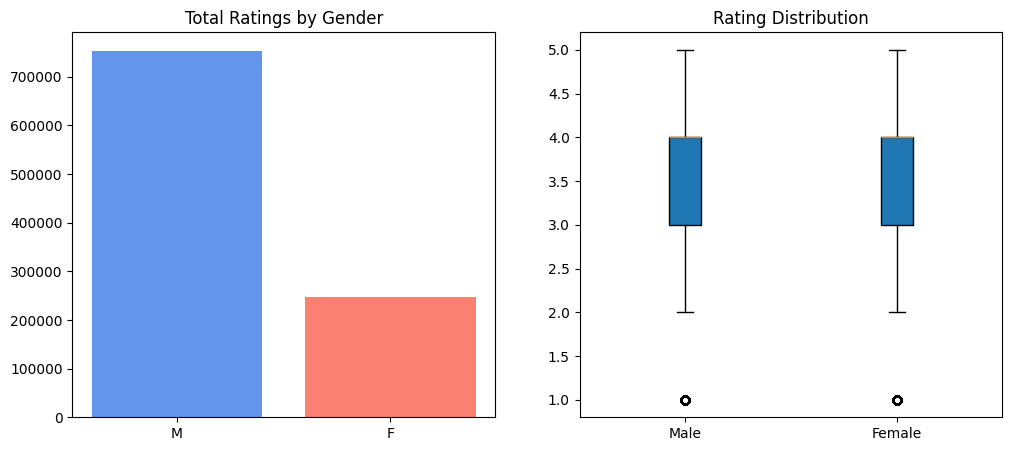

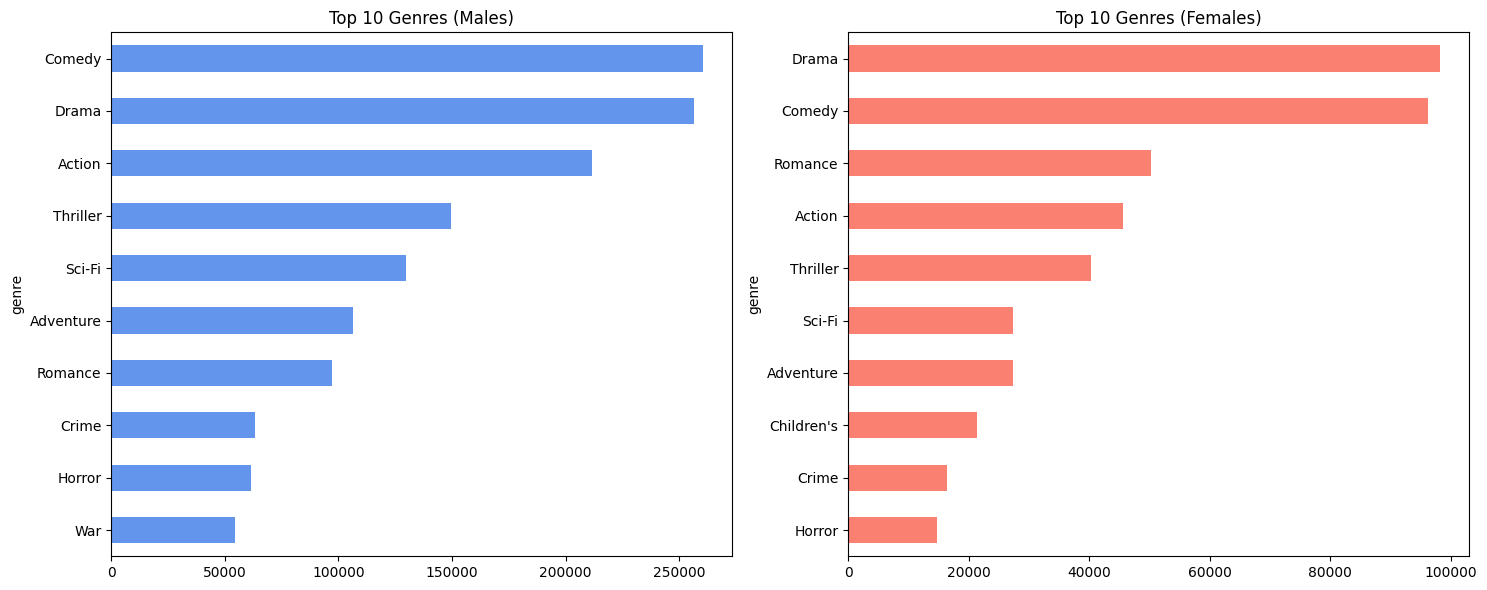

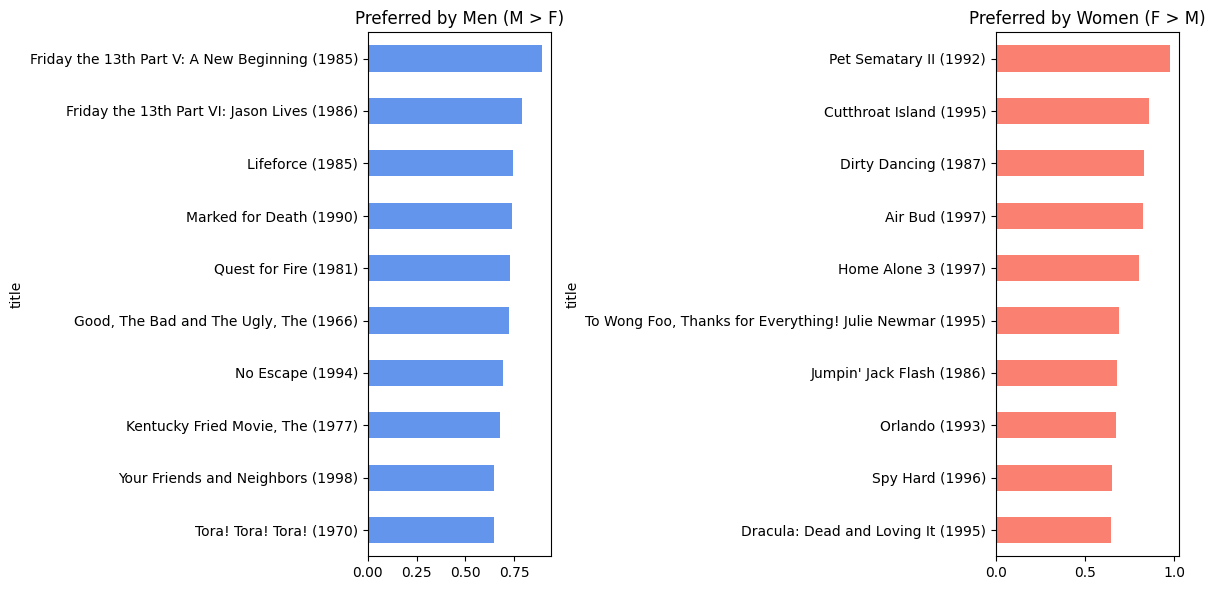

In [4]:
plot_gender_distribution(data)
plot_genre_preferences(data)
plot_gender_gap(data)

In [5]:
counts = build_counts_table(data)
sim_matrix = similarity_matrix_vectorized(counts)
sim_df = pd.DataFrame(sim_matrix, index=counts.index, columns=counts.index)
print("Similarity matrix computed successfully.")

Similarity matrix computed successfully.


In [6]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(data, test_size=0.2, random_state=42)

mae = evaluate_mae(train, test, sim_df, m_neighbors=20)
print(f"Global MAE: {mae:.4f}")

Global MAE: 0.6900
